<a href="https://colab.research.google.com/github/Yaaxek/TelecomX-Parte2-Churn/blob/main/TelecomX_Parte2_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X: Predicción de Cancelación (Churn)**

##**🎯 Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a i construir un pipeline robusto para esta etapa inicial de modelado.

##**🛠️ Preparación de los Datos**

###**Extracción del Archivo Tratado**

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd

In [20]:
pd.set_option('display.max_columns', None)

In [21]:
datos=pd.read_csv('/content/drive/MyDrive/TelecomX_LATAM/datos_tratados.csv')
datos

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667,4
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667,3
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333,2
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333,3
7039,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667,3
7040,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667,2
7041,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667,5


###**Exploracion de datos**

In [22]:
datos.shape

(7043, 23)

In [23]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Churn               7043 non-null   int64  
 2   gender              7043 non-null   object 
 3   SeniorCitizen       7043 non-null   int64  
 4   Partner             7043 non-null   int64  
 5   Dependents          7043 non-null   int64  
 6   tenure              7043 non-null   int64  
 7   PhoneService        7043 non-null   int64  
 8   MultipleLines       7043 non-null   int64  
 9   InternetService     7043 non-null   object 
 10  OnlineSecurity      7043 non-null   int64  
 11  OnlineBackup        7043 non-null   int64  
 12  DeviceProtection    7043 non-null   int64  
 13  TechSupport         7043 non-null   int64  
 14  StreamingTV         7043 non-null   int64  
 15  StreamingMovies     7043 non-null   int64  
 16  Contra

In [24]:
datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158723,3.362914
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003002,2.062031
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.183333,1.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.345000,3.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.995000,5.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333,8.000000


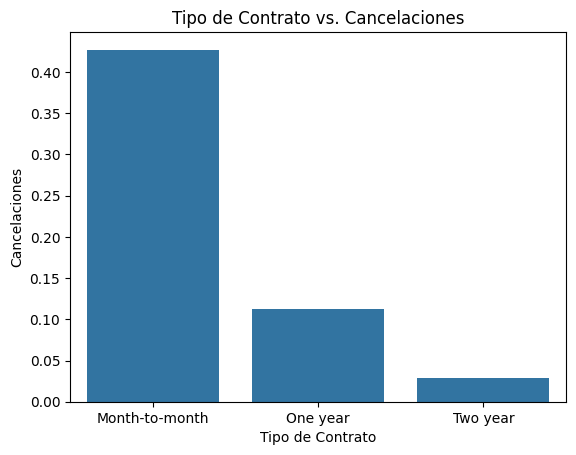

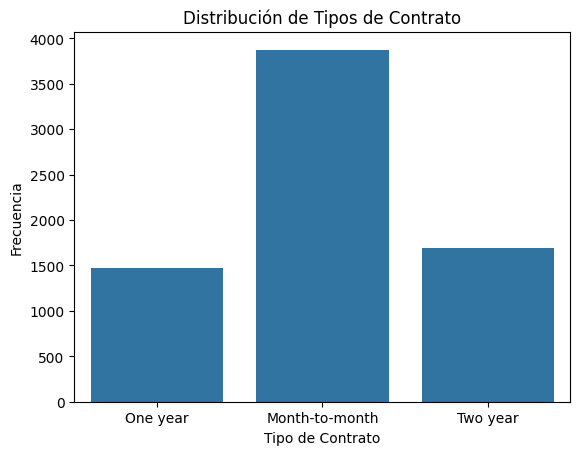

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_contract=datos.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(x='Contract',y='Churn',data=avg_contract)
plt.title('Tipo de Contrato vs. Cancelaciones')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cancelaciones')
plt.show()

sns.countplot(data=datos, x='Contract')
plt.title('Distribución de Tipos de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Frecuencia')
plt.show()

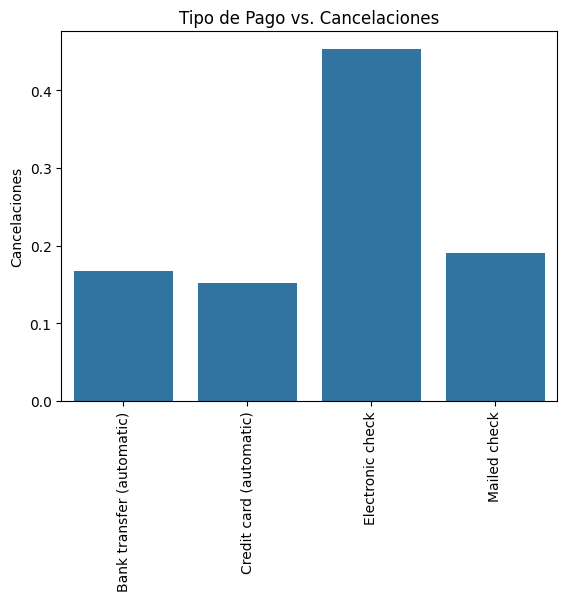

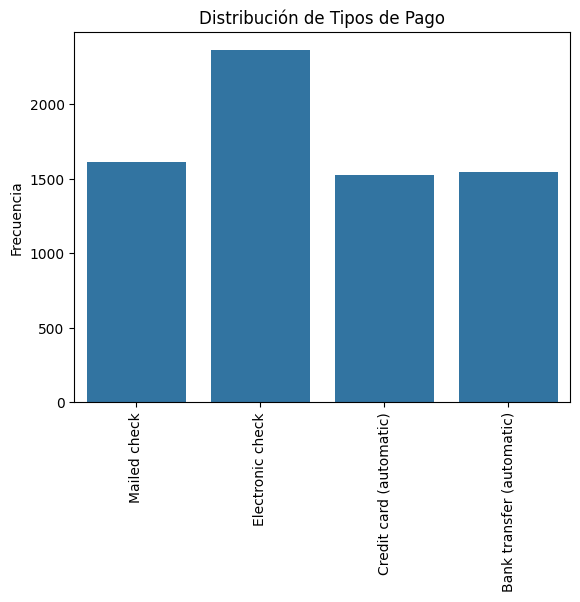

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_contract=datos.groupby('PaymentMethod')['Churn'].mean().reset_index()
sns.barplot(x='PaymentMethod',y='Churn',data=avg_contract)
plt.title('Tipo de Pago vs. Cancelaciones')
plt.xlabel('')
plt.ylabel('Cancelaciones')
plt.xticks(rotation=90)
plt.show()

sns.countplot(data=datos, x='PaymentMethod')
plt.title('Distribución de Tipos de Pago')
plt.xlabel('')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

###**Eliminación de Columnas Irrelevantes**

In [27]:
datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'Cantidad_Servicios'],
      dtype='object')

In [28]:
datos.drop(columns='customerID', inplace=True)

In [29]:
datos.sample(5)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
4138,0,Female,0,0,0,68,1,0,0,0,0,0,0,0,0,Two year,0,Bank transfer (automatic),20.05,1386.90,0.668333,1
4840,1,Female,0,0,0,13,1,1,Fiber optic,1,1,0,0,1,0,Month-to-month,1,Electronic check,96.65,1244.50,3.221667,5
6641,0,Male,0,1,1,72,0,0,DSL,1,1,1,1,1,1,Two year,1,Credit card (automatic),65.25,4478.85,2.175000,6
1919,1,Male,0,1,0,53,0,0,DSL,0,1,1,1,1,1,One year,1,Electronic check,60.45,3184.25,2.015000,5
2254,0,Male,0,0,0,24,1,0,DSL,0,0,0,1,0,0,Month-to-month,1,Credit card (automatic),51.10,1269.60,1.703333,2


####**NOTA:**
La proporción de clientes activos es aproximadamente 73.46%, mientras que el 26.54% cancelaron el servicio. Esto indica la presencia de un desbalance moderado entre las clases. Aunque no es extremo, puede influir en el desempeño de los modelos predictivos, ya que estos podrían favorecer la clase mayoritaria. Por ello, será importante considerar métricas adecuadas y, de ser necesario, aplicar técnicas para manejar el desbalance.

In [30]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Churn               7043 non-null   int64  
 1   gender              7043 non-null   object 
 2   SeniorCitizen       7043 non-null   int64  
 3   Partner             7043 non-null   int64  
 4   Dependents          7043 non-null   int64  
 5   tenure              7043 non-null   int64  
 6   PhoneService        7043 non-null   int64  
 7   MultipleLines       7043 non-null   int64  
 8   InternetService     7043 non-null   object 
 9   OnlineSecurity      7043 non-null   int64  
 10  OnlineBackup        7043 non-null   int64  
 11  DeviceProtection    7043 non-null   int64  
 12  TechSupport         7043 non-null   int64  
 13  StreamingTV         7043 non-null   int64  
 14  StreamingMovies     7043 non-null   int64  
 15  Contract            7043 non-null   object 
 16  Paperl

###**Encoding**

In [31]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
df_model=datos.copy()
categoricas=['gender','InternetService','Contract','PaymentMethod']

encoder=OneHotEncoder(drop='if_binary',sparse_output=False)
encoded=encoder.fit_transform(df_model[categoricas])
encoded_cols=encoder.get_feature_names_out(categoricas)
df_encoded=pd.DataFrame(encoded,columns=encoded_cols,index=df_model.index)
df_encoded=df_encoded.astype(int)
datos=pd.concat([df_model.drop(columns=categoricas),df_encoded],axis=1)


In [33]:
datos.sample(5)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios,gender_Male,InternetService_0,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1926,0,0,0,0,3,1,0,0,0,1,0,0,0,1,74.75,238.10,2.491667,2,0,0,0,1,1,0,0,0,0,0,1
3385,0,0,1,1,71,1,0,0,0,0,0,0,0,0,19.85,1326.35,0.661667,1,0,1,0,0,0,0,1,1,0,0,0
4099,0,0,1,1,69,1,0,0,1,1,1,0,0,0,59.10,4134.70,1.970000,4,0,0,1,0,0,1,0,1,0,0,0
6600,1,1,1,0,24,0,0,0,0,1,0,0,1,1,40.65,933.30,1.355000,2,0,0,1,0,1,0,0,0,1,0,0
2254,0,0,0,0,24,1,0,0,0,0,1,0,0,1,51.10,1269.60,1.703333,2,1,0,1,0,1,0,0,0,1,0,0


###**Verificación de la Proporción de Cancelación (Churn)**

In [34]:
datos['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [35]:
datos.Churn.value_counts(normalize=True)*100

,proportion
Churn,
0,73.463013
1,26.536987


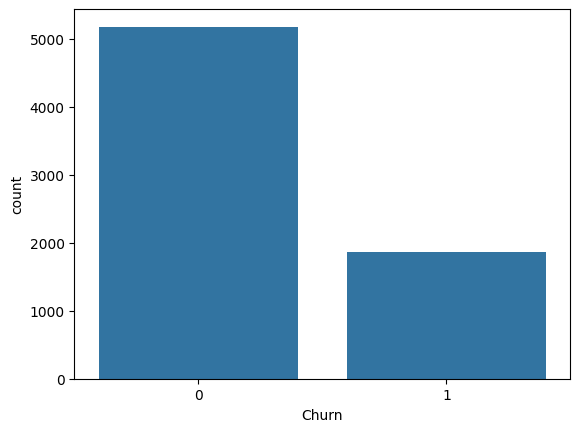

In [36]:
import seaborn as sns
sns.countplot(data=datos,x='Churn');

##**🎯 Correlación y Selección de Variables**

###**Análisis de Correlación**

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

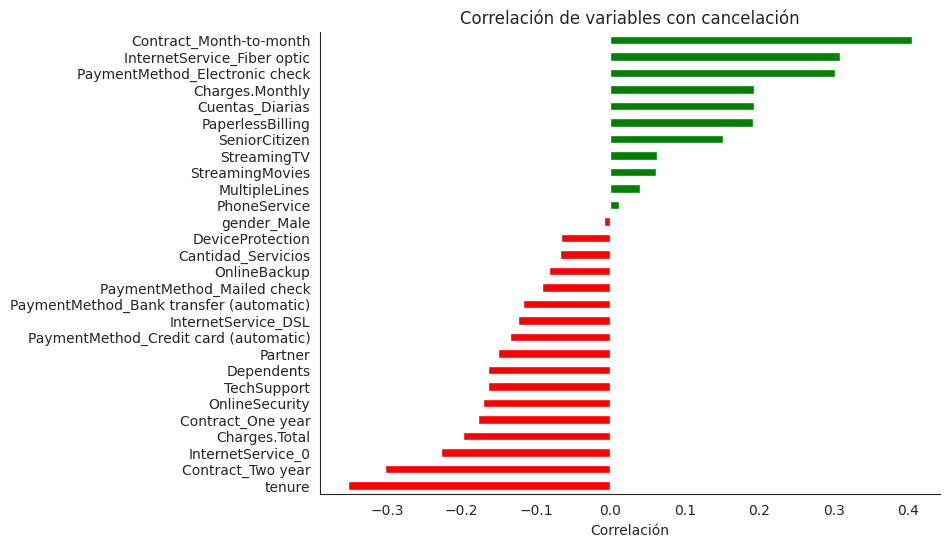

In [196]:
corr_churn = datos.corr()["Churn"].drop("Churn").sort_values()

sns.set_style("white")

plt.figure(figsize=(8,6))
ax = corr_churn.plot(kind="barh", color=['red' if x < 0 else 'green' for x in corr_churn.sort_values()])

sns.despine(top=True, right=True)
plt.xlabel("Correlación")
plt.ylabel("")
plt.title("Correlación de variables con cancelación")
plt.show()

####**NOTA:**
Para facilitar la interpretación, se analizó la correlación de cada variable con la cancelación. Se observa que variables como tenure, Contract y Charges.Monthly presentan mayor relación con churn, lo que sugiere que pueden ser relevantes para el modelo predictivo.

###**Análisis Dirigido**

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

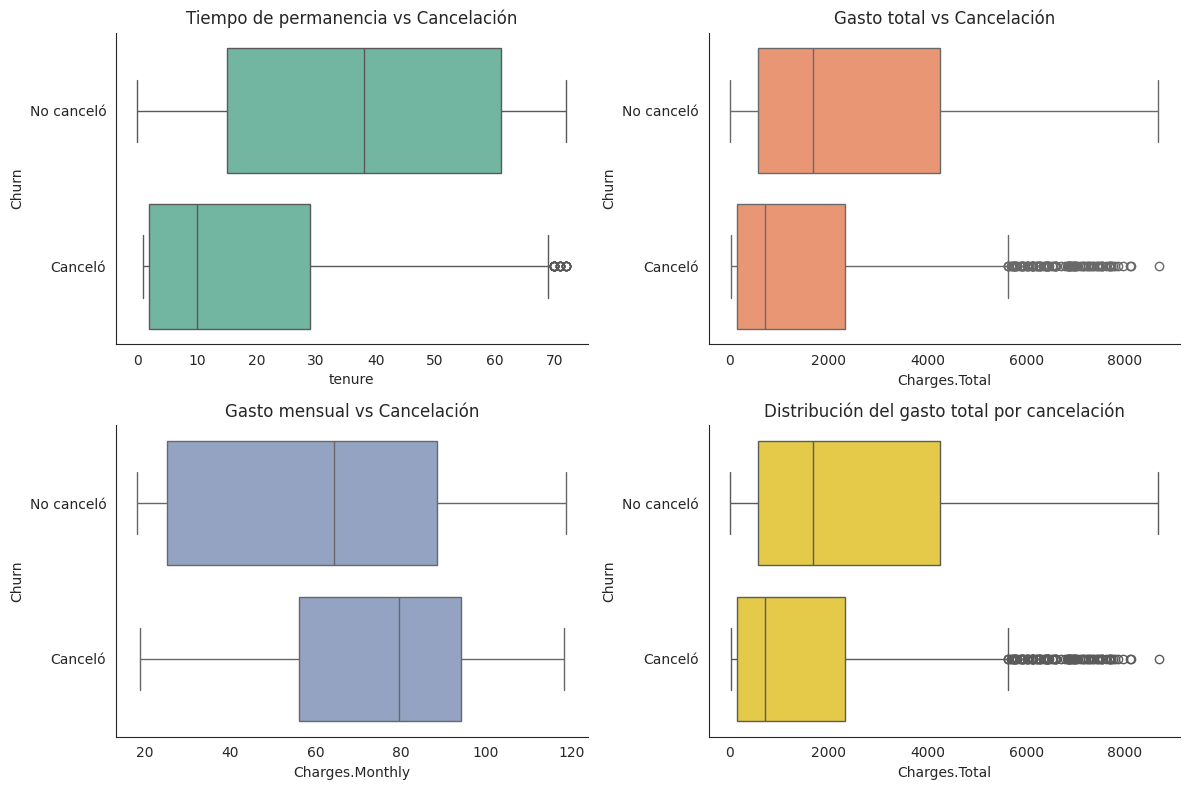

In [40]:
sns.set_style("white")

temp = datos[["Churn", "tenure", "Charges.Total", "Charges.Monthly"]].copy()
temp["Churn"] = temp["Churn"].map({0: "No canceló", 1: "Canceló"})

fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(data=temp, x="tenure", y="Churn", ax=axes[0,0], color="#66c2a5")
axes[0,0].set_title("Tiempo de permanencia vs Cancelación")

sns.boxplot(data=temp, x="Charges.Total", y="Churn", ax=axes[0,1], color="#fc8d62")
axes[0,1].set_title("Gasto total vs Cancelación")

sns.boxplot(data=temp, x="Charges.Monthly", y="Churn", ax=axes[1,0], color="#8da0cb")
axes[1,0].set_title("Gasto mensual vs Cancelación")

sns.boxplot(data=temp, x="Charges.Total", y="Churn", ax=axes[1,1], color="#ffd92f")
axes[1,1].set_title("Distribución del gasto total por cancelación")

sns.despine()
plt.tight_layout()
plt.show()

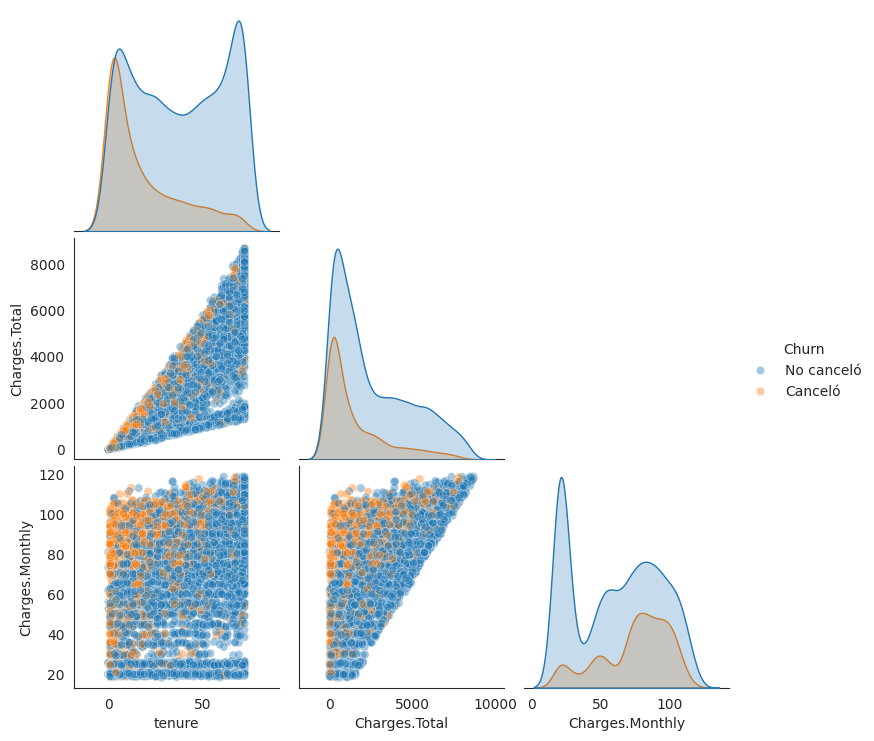

In [41]:
sns.set_style("white")
pair_data = datos[["tenure", "Charges.Total", "Charges.Monthly", "Churn"]].copy()

pair_data["Churn"] = pair_data["Churn"].map({0: "No canceló", 1: "Canceló"})
sns.pairplot(
    pair_data,
    hue="Churn",
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha":0.4}
)

plt.show()

####**NOTA:**
Los gráficos muestran patrones claros en relación con la cancelación. Se observa que los clientes que cancelan presentan menor tiempo de permanencia y menor gasto total, lo que sugiere que los clientes más nuevos tienen mayor probabilidad de abandonar el servicio. Asimismo, se identifica que los clientes que cancelan tienden a tener un gasto mensual ligeramente mayor, lo que podría indicar sensibilidad al precio. Estos resultados coinciden con la matriz de correlación y sugieren que estas variables son relevantes para el modelo predictivo.

##**🤖 Modelado Predictivo**

###**Separación de Datos**

In [221]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline
import numpy as np

In [121]:
X=datos.drop(columns='Churn')
y=datos['Churn']

###**Creación de Modelos**

In [122]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1000,stratify=y)

In [124]:
def evaluar_modelo_cv(nombre,modelo,X_train,y_train,n_splits=5):
  skf=StratifiedKFold(n_splits=n_splits,shuffle=True, random_state=1000)
  scoring={
      'accuracy':'accuracy',
      'precision':'precision',
      'recall':'recall',
      'f1':'f1'
      }
  resultados=cross_validate(modelo,X_train,y_train,cv=skf,scoring=scoring,return_train_score=False)
  resumen=pd.DataFrame({
      'Modelo':[nombre],
      'Accuracy':[resultados['test_accuracy'].mean()],
      'Precision':[resultados['test_precision'].mean()],
      'Recall':[resultados['test_recall'].mean()],
      'F1':[resultados['test_f1'].mean()]
  })
  return resumen

In [157]:
def evaluar_modelo_test(nombre,modelo,X_train,y_train,X_test,y_test):
  modelo.fit(X_train,y_train)
  y_pred=modelo.predict(X_test)
  resultados = pd.DataFrame({
      "Modelo": [nombre],
      "Accuracy_test": [accuracy_score(y_test, y_pred)],
      "Precision_test": [precision_score(y_test, y_pred)],
      "Recall_test": [recall_score(y_test, y_pred)],
      "F1_test": [f1_score(y_test, y_pred)]
    })
  print(f'\n{nombre}')
  print('*'*60)
  print(classification_report(y_test,y_pred))
  return resultados

###**Sin balanceo**

####**Baseline**

In [158]:
dummy=DummyClassifier(strategy='stratified',random_state=1000)
res_dummy_cv=evaluar_modelo('Dummy Baseline-Train',dummy,X_train,y_train)
res_dummy_test=evaluar_modelo_test('Dummy Baseline-Test',dummy,X_train,y_train,X_test,y_test)


Dummy Baseline-Test
************************************************************
              precision    recall  f1-score   support

           0       0.73      0.72      0.73      1035
           1       0.26      0.27      0.27       374

    accuracy                           0.60      1409
   macro avg       0.50      0.50      0.50      1409
weighted avg       0.61      0.60      0.61      1409



####**Logistic Regression**

In [159]:
pipe_lr=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter=2000,random_state=1000))
])
res_lr_cv=evaluar_modelo_cv('Logistic Regression',pipe_lr,X_train,y_train)
res_lr_test=evaluar_modelo_test('Logistic Regression',pipe_lr,X_train,y_train,X_test,y_test)


Logistic Regression
************************************************************
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



####**Random Forest**

In [162]:
pipe_rf=Pipeline([
    ('model',RandomForestClassifier(random_state=1000, max_depth=10))
])
res_rf_cv=evaluar_modelo('Random Forest',pipe_rf,X_train,y_train)
res_rf_test=evaluar_modelo_test('Random Forest',pipe_rf,X_train,y_train,X_test,y_test)


Random Forest
************************************************************
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



####**KNN**

In [161]:
pipe_knn=Pipeline([
    ('scaler',StandardScaler()),
    ('model',KNeighborsClassifier())
])
res_knn_cv=evaluar_modelo('KNN',pipe_knn,X_train,y_train)
res_knn_test=evaluar_modelo_test('KNN',pipe_knn,X_train,y_train,X_test,y_test)


KNN
************************************************************
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1035
           1       0.54      0.51      0.52       374

    accuracy                           0.76      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.76      0.75      1409



####**Comparativa de resultados sin balancear**

In [165]:
resumen_cv_sinb=pd.concat([res_dummy_cv,res_lr_cv,res_rf_cv,res_knn],ignore_index=True)
resumen_cv_sinb.sort_values(by='Recall',ascending=False)

,Modelo,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.805644,0.660756,0.551839,0.601131
2,Random Forest,0.802450,0.666644,0.514381,0.579907
3,KNN,0.759853,0.552255,0.499666,0.524448
0,Dummy Baseline-Train,0.610045,0.271178,0.278261,0.274674


In [167]:
resumen_test_sinb=pd.concat([res_dummy_test,res_lr_test,res_rf_test,res_knn_test],ignore_index=True)
resumen_test_sinb.sort_values(by='Recall_test',ascending=False)

,Modelo,Accuracy_test,Precision_test,Recall_test,F1_test
1,Logistic Regression,0.803407,0.651090,0.558824,0.601439
3,KNN,0.755145,0.541311,0.508021,0.524138
2,Random Forest,0.792761,0.642361,0.494652,0.558912
0,Dummy Baseline-Test,0.604684,0.263566,0.272727,0.268068


###**Con Balanceo**

####**Logistic + SMOTE**

In [173]:
pipe_lr_smote=imbPipeline([
    ('smote',SMOTE(random_state=1000)),
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter=2000,random_state=1000))
])
res_lr_smote_cv = evaluar_modelo_cv("Logistic + SMOTE", pipe_lr_smote, X_train, y_train)
res_lr_smote_test = evaluar_modelo_test("Logistic + SMOTE", pipe_lr_smote, X_train, y_train, X_test, y_test)


Logistic + SMOTE
************************************************************
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.60      0.60      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



####**Random Forest + SMOTE**

In [175]:
pipe_rf_smote=imbPipeline([
    ('smote',SMOTE(random_state=1000)),
    ('model',RandomForestClassifier(random_state=1000, max_depth=10))
])
res_rf_smote_cv = evaluar_modelo_cv("Random Forest + SMOTE", pipe_rf_smote, X_train, y_train)
res_rf_smote_test = evaluar_modelo_test("Random Forest + SMOTE", pipe_rf_smote, X_train, y_train, X_test, y_test)


Random Forest + SMOTE
************************************************************
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1035
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



####**KNN + SMOTE**

In [176]:
pipe_knn_smote=imbPipeline([
    ('smote',SMOTE(random_state=1000)),
    ('scaler',StandardScaler()),
    ('model',KNeighborsClassifier())
])
res_knn_smote_cv = evaluar_modelo_cv("KNN + SMOTE", pipe_knn_smote, X_train, y_train)
res_knn_smote_test = evaluar_modelo_test("KNN + SMOTE", pipe_knn_smote, X_train, y_train, X_test, y_test)


KNN + SMOTE
************************************************************
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1035
           1       0.51      0.60      0.55       374

    accuracy                           0.74      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.74      0.75      1409



####**Comparativa de resultados balanceados**

In [198]:
resume_cv_conb=pd.concat([res_lr_smote_cv,res_rf_smote_cv,res_knn_smote_cv],ignore_index=True)
resume_cv_conb.sort_values(by='Recall',ascending=False)

,Modelo,Accuracy,Precision,Recall,F1
1,Random Forest + SMOTE,0.775824,0.565223,0.677592,0.616106
0,Logistic + SMOTE,0.795526,0.613622,0.621405,0.617307
2,KNN + SMOTE,0.750091,0.525515,0.592642,0.556930


In [197]:
resume_test_conb=pd.concat([res_lr_smote_test,res_rf_smote_test,res_knn_smote_test],ignore_index=True)
resume_test_conb.sort_values(by='Recall_test',ascending=False)

,Modelo,Accuracy_test,Precision_test,Recall_test,F1_test
1,Random Forest + SMOTE,0.781405,0.574661,0.679144,0.622549
2,KNN + SMOTE,0.743790,0.514874,0.601604,0.554871
0,Logistic + SMOTE,0.786373,0.597333,0.598930,0.598131


###**Trataremos: Random Forest + SMOTE**

Aunque la métrica F1 permite evaluar el equilibrio entre precisión y recall, en este análisis se priorizó la métrica recall debido al contexto del problema. En el caso de la predicción de cancelación de clientes, resulta más relevante identificar correctamente a la mayor cantidad posible de clientes que cancelan el servicio, incluso si esto implica cometer más falsos positivos. No obstante, el F1-score también se consideró para asegurar que el modelo mantuviera un buen equilibrio general.

In [220]:
X_res, y_res = SMOTE(random_state=1000).fit_resample(X_train, y_train)

print(f'Distribución original: {y_train.value_counts(normalize=True)}\n', '*'*40, f'\nDespués de SMOTE: {y_res.value_counts(normalize=True)}')


Distribución original: Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
 **************************************** 
Después de SMOTE: Churn
1    0.5
0    0.5
Name: proportion, dtype: float64


In [223]:
param_grid={
    'model__n_estimators':[100,150,200],
    'model__max_depth':[5,10,15],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=1000)
grid=GridSearchCV(estimator=pipe_rf_smote, param_grid=param_grid, cv=cv, scoring='recall', n_jobs=-1,verbose=1)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1000, shuffle=True),
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=1000)),
                                       ('model',
                                        RandomForestClassifier(max_depth=10,
                                                               random_state=1000))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 150, 200]},
             scoring='recall', verbose=1)

In [225]:
print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor score CV:")
print(grid.best_score_)

Mejores parámetros:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Mejor score CV:
0.7698996655518394


In [229]:
grid.best_estimator_
res_rf_grid_cv=evaluar_modelo_cv('Random Forest SMOTE Grid - Train',grid.best_estimator_,X_train,y_train)
res_rf_grid_test=evaluar_modelo_test('Random Forest Grid - Test',grid.best_estimator_,X_train,y_train,X_test,y_test)


Random Forest Grid - Test
************************************************************
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [234]:
comparacion_rf = pd.concat([res_rf_smote_cv, res_rf_grid_cv],ignore_index=True)
comparacion_rf.sort_values(by='Recall',ascending=False)

,Modelo,Accuracy,Precision,Recall,F1
1,Random Forest SMOTE Grid - Train,0.763579,0.538337,0.769900,0.633516
0,Random Forest + SMOTE,0.775824,0.565223,0.677592,0.616106


In [236]:
comparacion_rf_test = pd.concat([res_rf_smote_test, res_rf_grid_test], ignore_index=True)
comparacion_rf_test.sort_values(by='Recall_test',ascending=False)

,Modelo,Accuracy_test,Precision_test,Recall_test,F1_test
1,Random Forest Grid - Test,0.760114,0.534483,0.745989,0.622768
0,Random Forest + SMOTE,0.781405,0.574661,0.679144,0.622549


###**Champion: Random Forest + SMOTE + GRID**
####grid.best_estimator_


In [233]:
grid.best_estimator_

Pipeline(steps=[('smote', SMOTE(random_state=1000)),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_split=10,
                                        n_estimators=200, random_state=1000))])

####**Matriz de confusion**

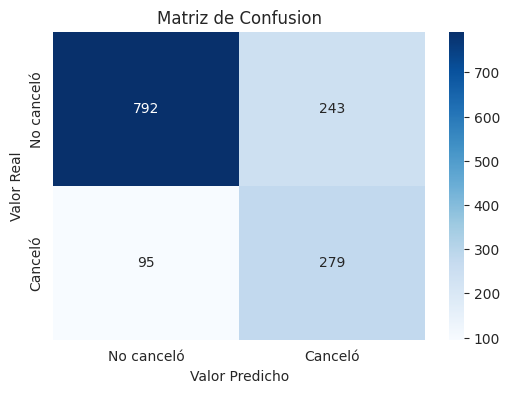

In [243]:
y_pred_test=grid.best_estimator_.predict(X_test)
cm=confusion_matrix(y_test,y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["No canceló","Canceló"],
yticklabels=["No canceló","Canceló"])
plt.title('Matriz de Confusion')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

#####**NOTA:**
La matriz de confusión muestra que el modelo identifica correctamente a la mayoría de los clientes que cancelan el servicio. En particular, logra detectar 279 de los clientes que efectivamente cancelaron, lo que se traduce en un recall de aproximadamente 0.75.

Aunque el modelo presenta algunos falsos positivos (243 casos), estos resultan menos críticos en el contexto del problema, ya que es preferible anticipar posibles cancelaciones a no detectarlas. En general, los resultados reflejan un buen desempeño del modelo para identificar clientes en riesgo de churn.

####**ROC + AUC**

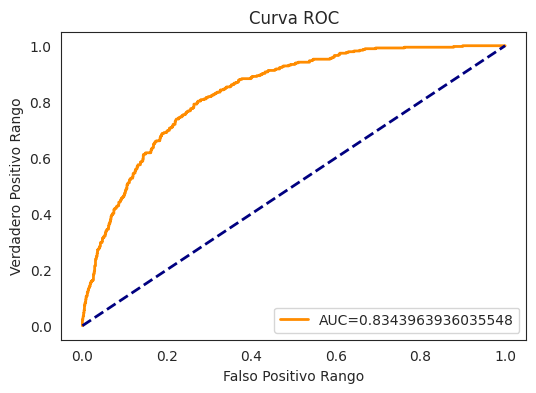

In [245]:
from sklearn.metrics import roc_curve, auc

y_val=grid.best_estimator_.predict_proba(X_test)[:,1]
fpr,tpr,threshold=roc_curve(y_test,y_val)
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'AUC={roc_auc}')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlabel('Falso Positivo Rango')
plt.ylabel('Verdadero Positivo Rango')
plt.title('Curva ROC')
plt.legend()
plt.show()

#####**NOTA:**
El modelo presenta un AUC de 0.83, lo que indica una buena capacidad discriminativa entre clientes que cancelan y los que permanecen.

####**Precision-recall + AP**

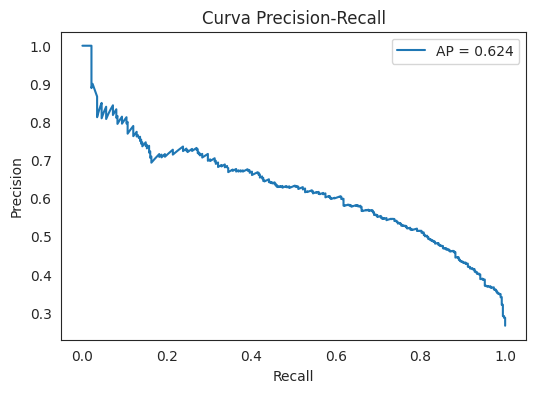

In [249]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_val)
ap = average_precision_score(y_test, y_val)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.show()

#####**NOTA:**
La curva Precision-Recall confirma que el modelo mantiene un buen equilibrio entre precisión y recall, incluso al aumentar la sensibilidad para detectar churn.

####**Variables con mayor relevancia**

In [251]:
grid.best_estimator_.fit(X_train,y_train)
importancias=pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':pipe_rf_smote.named_steps['model'].feature_importances_
}).sort_values(by='Importance',ascending=False)
importancias.head(10)

,Feature,Importance
3,tenure,0.103558
21,Contract_Month-to-month,0.092258
23,Contract_Two year,0.084701
13,Charges.Monthly,0.071868
14,Charges.Total,0.071696
15,Cuentas_Diarias,0.069541
22,Contract_One year,0.057269
9,TechSupport,0.057202
6,OnlineSecurity,0.052272
18,InternetService_0,0.045712


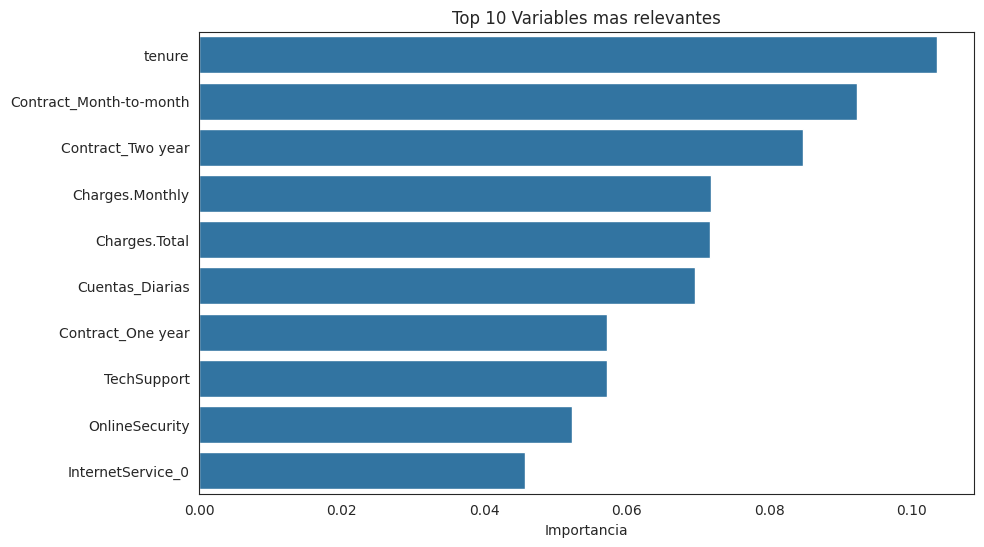

In [252]:
top_10=importancias.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_10,x='Importance',y='Feature')
plt.title('Top 10 Variables mas relevantes')
plt.xlabel('Importancia')
plt.ylabel('')
plt.show()

In [262]:
top_features = [
'tenure',
'Contract_Month-to-month',
'Contract_Two year',
'Charges.Monthly',
'Charges.Total',
'Cuentas_Diarias',
'Contract_One year',
'TechSupport',
'OnlineSecurity',
'InternetService_0'
]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf_params = {k.replace('model__', ''): v for k, v in grid.best_params_.items()}

pipe_rf_top = imbPipeline([
    ('smote', SMOTE(random_state=1000)),
    ('model', RandomForestClassifier(**rf_params, random_state=1000))
])
res_top_cv=evaluar_modelo_cv('Random Forest TOP FEATURES',pipe_rf_top,X_train_top,y_train)
res_top_test=evaluar_modelo_test('Random Forest TOP FEATURES',pipe_rf_top,X_train_top,y_train,X_test_top,y_test)


Random Forest TOP FEATURES
************************************************************
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [261]:
comparacion_rf = pd.concat([res_rf_grid_cv,res_top_cv],ignore_index=True)
comparacion_rf.sort_values(by='Recall',ascending=False)

,Modelo,Accuracy,Precision,Recall,F1
0,Random Forest SMOTE Grid - Train,0.763579,0.538337,0.769900,0.633516
1,Random Forest TOP FEATURES,0.756301,0.528235,0.760535,0.623431


In [258]:
comparacion_rf_test = pd.concat([res_rf_grid_test,res_top_test], ignore_index=True)
comparacion_rf_test.sort_values(by='Recall_test',ascending=False)

,Modelo,Accuracy_test,Precision_test,Recall_test,F1_test
1,Random Forest TOP FEATURES,0.753016,0.523810,0.764706,0.621739
0,Random Forest Grid - Test,0.760114,0.534483,0.745989,0.622768


#**📊 Evaluación Final del Modelo**

Se evaluaron los modelos Dummy Baseline, Regresión Logística, KNN y Random Forest (con SMOTE y optimización mediante GridSearch) utilizando las métricas de exactitud (accuracy), precisión (precision), recall, F1-score y matriz de confusión.

## 🔹 Exactitud (Accuracy)

El modelo con mejor exactitud fue la Regresión Logística (~0.80), seguido de Random Forest. Sin embargo, la exactitud no fue la métrica principal debido al desbalance de clases presente en el problema de churn.

## 🔹 Precisión (Precision)

La Regresión Logística presentó una precisión ligeramente superior en comparación con los demás modelos. Esto indica que cuando predice cancelación, suele acertar con mayor frecuencia, aunque detecta menos casos reales de churn.

## 🔹 Recall (Métrica principal)

El mejor desempeño en recall lo obtuvo:

👉 **Random Forest con SMOTE optimizado mediante GridSearch (~0.746 en test)**

Esto significa que el modelo logró identificar aproximadamente el 75% de los clientes que cancelaron el servicio, lo cual es clave en el contexto del negocio.

## 🔹 F1-score

El F1-score también fue ligeramente superior en:

👉 **Random Forest con SMOTE optimizado mediante GridSearch (~0.623)**

Esto confirma que mantiene un buen equilibrio entre precisión y recall, aunque la prioridad del análisis fue maximizar el recall.

## 🔹 Matriz de confusión

La matriz de confusión del modelo final mostró:

- 279 cancelaciones detectadas correctamente  
- 95 cancelaciones no detectadas  
- algunos falsos positivos (243), lo cual es aceptable en este contexto  

Esto indica que el modelo es eficaz para identificar clientes en riesgo.

## 🔹 Evaluación adicional

Adicionalmente, se probó una versión del modelo utilizando únicamente las variables más importantes. Aunque presentó resultados similares, no superó el desempeño del modelo completo, por lo que se decidió mantener todas las variables en la versión final.

#**Serializacion del modelo**

In [263]:
import pickle

champion_model = grid.best_estimator_

with open("champion_model.pkl", "wb") as f:
    pickle.dump(champion_model, f)

print("Modelo final guardado correctamente")

Modelo final guardado correctamente


# **🔎 Análisis Crítico y Comparación de Modelos**

## 🏆 ¿Cuál modelo tuvo el mejor desempeño?

El modelo con mejor desempeño general fue:

👉 **Random Forest con SMOTE optimizado mediante GridSearch**

Aunque se probó una versión reducida utilizando únicamente las variables más importantes, el modelo completo mostró mejores resultados generales, manteniendo mayor estabilidad entre entrenamiento y prueba, además de un mejor equilibrio entre precisión, recall y F1-score.

Por esta razón, se eligió el modelo completo como modelo final para la predicción de churn.

## ⚠️ Overfitting y Underfitting

### 🔹 Overfitting

No se observaron señales claras de overfitting.

👉 Evidencia:

- métricas similares entre entrenamiento y test  
- ejemplo: recall train ≈ 0.77 vs recall test ≈ 0.75  

Esto indica buena capacidad de generalización.

Además, el uso de:

- SMOTE  
- validación cruzada  
- ajuste con GridSearch  
- control de hiperparámetros  

ayudó a evitar sobreajuste.

### 🔹 Underfitting

Sí se observó underfitting en algunos modelos:

#### 🔸 Dummy Baseline  
Presentó el peor desempeño en todas las métricas, lo que confirma que es demasiado simple para el problema.

#### 🔸 KNN  
Mostró resultados más bajos en todas las métricas, lo que sugiere que no captura adecuadamente las relaciones del dataset.

👉 Posibles causas:

- sensibilidad al ruido  
- limitaciones ante datos complejos  
- dependencia de la escala y distribución

---

# 🧾 Conclusión Final del Proyecto

El análisis permitió identificar que la cancelación de clientes está fuertemente influida por la **antigüedad del cliente (tenure)**, el **tipo de contrato**, el **nivel de gasto** y la contratación de **servicios complementarios**.

Los principales hallazgos fueron:

- los clientes con menor antigüedad presentan mayor probabilidad de cancelar  
- los contratos mensuales se asocian con mayor churn  
- los contratos de largo plazo favorecen la retención  
- los cargos mensuales elevados pueden aumentar el riesgo de cancelación  
- servicios como TechSupport y OnlineSecurity ayudan a reducir el churn  

El modelo **Random Forest con SMOTE optimizado mediante GridSearch** fue el más adecuado para este problema, ya que logró el mejor desempeño en la detección de clientes con riesgo de cancelar, manteniendo buen equilibrio entre métricas y estabilidad general.

## 💡 Estrategias de retención propuestas

Con base en los resultados, se sugieren las siguientes estrategias:

- enfocar acciones en clientes nuevos mediante programas de fidelización  
- incentivar contratos de largo plazo  
- monitorear clientes con cargos mensuales altos  
- promover servicios de soporte y seguridad  
- implementar alertas tempranas de churn con el modelo predictivo

En conjunto, el análisis no solo permitió desarrollar un modelo predictivo sólido, sino también generar recomendaciones estratégicas para reducir la cancelación y mejorar la retención de clientes.